# Credit Card Fraud Detection on an Imbalanced Dataset

**Goal:** build a fraud classifier and handle the extreme class imbalance
that makes this problem hard (~0.1–0.5% of transactions are fraud).

This project is built entirely from concepts in the **CampusX Machine
Learning playlist**:

| Concept (CampusX) | Where it's used below |
|---|---|
| EDA & feature scaling (Standard/Robust Scaler) | Sections 2–3 |
| Train/test split & data leakage | Section 3 |
| Logistic Regression | Sections 4–5 |
| The "accuracy paradox" on imbalanced data | Section 4 |
| Handling imbalanced datasets (undersampling, SMOTE, class weights) | Section 5 |
| Decision Trees | Section 6 |
| Random Forest (Bagging) | Section 6 |
| Gradient Boosting (XGBoost) | Section 6 |
| K-Fold Cross Validation & GridSearchCV/RandomizedSearchCV | Section 7 |
| Confusion Matrix, Precision, Recall, F1, ROC-AUC, PR-AUC | Sections 4, 6, 8 |
| Threshold tuning | Section 9 |

### Dataset
This notebook is written for the classic **Kaggle "Credit Card Fraud
Detection" dataset** (anonymized European cardholder transactions,
Sept 2013): 284,807 transactions, 492 frauds (0.172%), features
`V1..V28` (PCA components), `Time`, `Amount`, `Class`.

Download it here and place `creditcard.csv` next to this notebook to
use the real data: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**If `creditcard.csv` isn't found, the notebook auto-generates a
synthetic dataset with the identical schema and a similar fraud rate**,
so every cell below still runs end-to-end and produces real output.
Swap in the real CSV any time — no other code changes needed.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.datasets import make_classification


from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
def generate_synthetic_creditcard_data(n_samples=50000, fraud_ratio=0.0025, random_state=RANDOM_STATE):
    # Synthetic stand-in with the same schema as the Kaggle creditcard.csv:
    # Time, V1..V28 (PCA-like components), Amount, Class.
    # Used only when the real file isn't available, so the pipeline still runs.
    n_features = 28
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=12,
        n_redundant=6,
        n_clusters_per_class=2,
        weights=[1 - fraud_ratio, fraud_ratio],
        class_sep=1.1,
        flip_y=0.001,
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    df_syn = pd.DataFrame(X, columns=[f'V{i}' for i in range(1, n_features + 1)])
    df_syn['Time'] = rng.uniform(0, 172792, size=n_samples)
    amount = rng.lognormal(mean=3.0, sigma=1.2, size=n_samples)
    amount[y == 1] *= 0.6  # fraud tends to skew toward smaller amounts, like the real dataset
    df_syn['Amount'] = np.round(amount, 2)
    df_syn['Class'] = y
    cols = ['Time'] + [f'V{i}' for i in range(1, n_features + 1)] + ['Amount', 'Class']
    return df_syn[cols]


DATA_PATH_CANDIDATES = ['creditcard.csv', '/mnt/user-data/uploads/creditcard.csv']
data_path = next((p for p in DATA_PATH_CANDIDATES if os.path.exists(p)), None)

if data_path:
    df = pd.read_csv(data_path)
    print(f'Loaded REAL dataset from {data_path} -> shape {df.shape}')
else:
    print('creditcard.csv not found locally.')
    print('Generating a SYNTHETIC dataset with the same schema so the notebook runs end-to-end.')
    print('For authentic results, download the real dataset from:')
    print('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')
    df = generate_synthetic_creditcard_data()
    print(f'Synthetic dataset shape: {df.shape}')

df.head()

Loaded REAL dataset from creditcard.csv -> shape (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis

Class distribution:
  Genuine (0): 284,315  (99.8273%)
  Fraud   (1): 492  (0.1727%)
  Imbalance ratio -> 1 fraud per 577 genuine transactions


/var/folders/n6/td1vk32x2cq2jg03qkh3bd4w0000gn/T/ipykernel_9252/2610072521.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette=['#4C72B0', '#C44E52'], ax=ax)
/var/folders/n6/td1vk32x2cq2jg03qkh3bd4w0000gn/T/ipykernel_9252/2610072521.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Genuine (0)', 'Fraud (1)'])


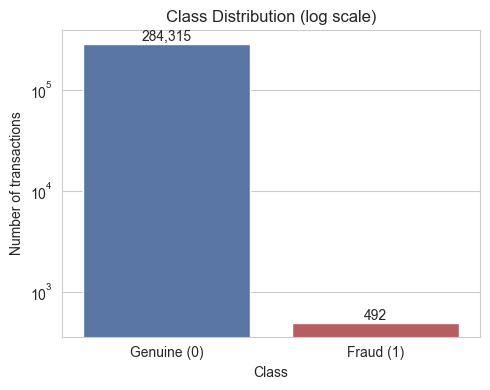

In [3]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f"  Genuine (0): {class_counts[0]:,}  ({class_pct[0]:.4f}%)")
print(f"  Fraud   (1): {class_counts[1]:,}  ({class_pct[1]:.4f}%)")
print(f"  Imbalance ratio -> 1 fraud per {class_counts[0] // class_counts[1]} genuine transactions")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette=['#4C72B0', '#C44E52'], ax=ax)
ax.set_xticklabels(['Genuine (0)', 'Fraud (1)'])
ax.set_ylabel('Number of transactions')
ax.set_title('Class Distribution (log scale)')
ax.set_yscale('log')
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

/var/folders/n6/td1vk32x2cq2jg03qkh3bd4w0000gn/T/ipykernel_9252/3295286895.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Genuine', 'Fraud'])


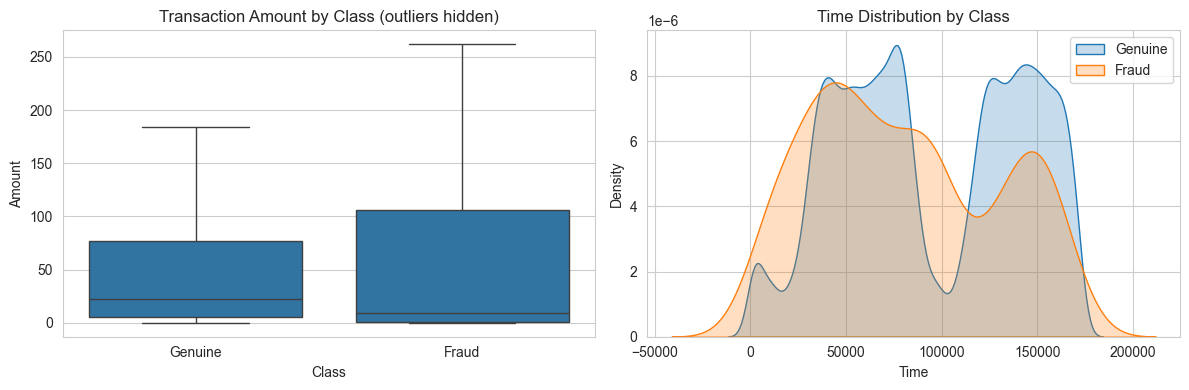

             mean    50%         std       max
Class                                         
0       88.291022  22.00  250.105092  25691.16
1      122.211321   9.25  256.683288   2125.87


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], showfliers=False)
axes[0].set_xticklabels(['Genuine', 'Fraud'])
axes[0].set_title('Transaction Amount by Class (outliers hidden)')

sns.kdeplot(df.loc[df['Class'] == 0, 'Time'], label='Genuine', ax=axes[1], fill=True)
sns.kdeplot(df.loc[df['Class'] == 1, 'Time'], label='Fraud', ax=axes[1], fill=True)
axes[1].set_title('Time Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe()[['mean', '50%', 'std', 'max']])

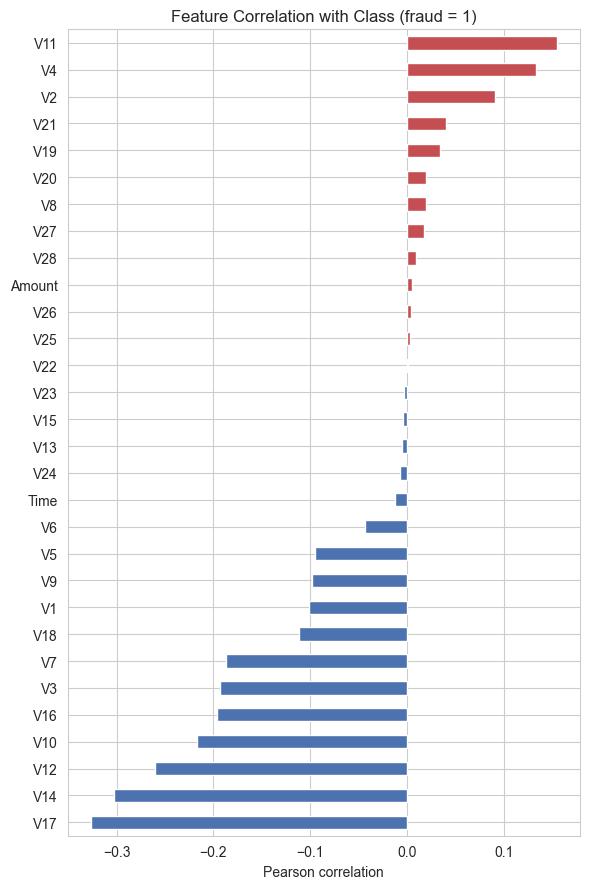

In [5]:
# Correlation of every feature with the target - a quick, CampusX-style
# feature-relevance check before modeling.
corr_with_class = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(6, 9))
corr_with_class.plot(kind='barh', ax=ax, color=np.where(corr_with_class > 0, '#C44E52', '#4C72B0'))
ax.set_title('Feature Correlation with Class (fraud = 1)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## 3. Preprocessing: Split First, Then Scale (avoiding leakage)

`V1..V28` are already PCA components on a similar scale in the real
dataset. `Time` and `Amount` are not, so we scale them with a
**RobustScaler** (robust to the heavy outliers fraud/high-value
transactions create). Critically, the **scaler is fit only on the
training split** and then applied to the test split — fitting on the
full dataset before splitting is a classic data-leakage mistake.

In [6]:
feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f'Train shape: {X_train.shape}, fraud rate: {y_train.mean()*100:.4f}%')
print(f'Test shape:  {X_test.shape}, fraud rate: {y_test.mean()*100:.4f}%')

scaler = RobustScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print('\nTime/Amount scaled using statistics from the TRAIN split only.')

Train shape: (213605, 30), fraud rate: 0.1727%
Test shape:  (71202, 30), fraud rate: 0.1727%

Time/Amount scaled using statistics from the TRAIN split only.


## 4. Baseline Model & the Accuracy Paradox

Train a plain Logistic Regression with no imbalance handling at all.
Watch what happens to **accuracy** vs. **recall on the fraud class**.

In [7]:
results = []  # collects one dict per experiment for the comparison tables later

def evaluate_model(name, y_true, y_pred, y_proba, verbose=True):
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
    }
    if verbose:
        print(f"--- {name} ---")
        print(f"Accuracy : {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}   Recall: {metrics['recall']:.4f}   F1: {metrics['f1']:.4f}")
        print(f"ROC-AUC  : {metrics['roc_auc']:.4f}   PR-AUC: {metrics['pr_auc']:.4f}")
        print(confusion_matrix(y_true, y_pred))
    results.append(metrics)
    return metrics

baseline_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_lr.fit(X_train, y_train)

y_pred = baseline_lr.predict(X_test)
y_proba = baseline_lr.predict_proba(X_test)[:, 1]

evaluate_model('Baseline LR (no imbalance handling)', y_test, y_pred, y_proba)

n_fraud_test = int(y_test.sum())
n_missed = n_fraud_test - int(((y_pred == 1) & (y_test == 1)).sum())
print(f"\n>>> The model looks 'accurate', but it missed {n_missed} of {n_fraud_test} "
      f"actual frauds in the test set. Accuracy is the wrong metric here.")

--- Baseline LR (no imbalance handling) ---
Accuracy : 0.9991
Precision: 0.8370   Recall: 0.6260   F1: 0.7163
ROC-AUC  : 0.9610   PR-AUC: 0.7147
[[71064    15]
 [   46    77]]

>>> The model looks 'accurate', but it missed 46 of 123 actual frauds in the test set. Accuracy is the wrong metric here.


## 5. Handling the Imbalance

Three standard techniques, all applied **only to the training data**
(never touch the test set — it must reflect real-world class
proportions):

1. **Class weighting** — penalize misclassifying the minority class more heavily.
2. **Random undersampling** — drop majority-class rows to balance classes.
3. **SMOTE** — synthesize new minority-class samples by interpolation.

Logistic Regression is kept fixed across all three so the comparison
isolates the effect of the resampling technique.

In [8]:
# 5a. Class-weight balancing
lr_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_cw.fit(X_train, y_train)
y_pred = lr_cw.predict(X_test)
y_proba = lr_cw.predict_proba(X_test)[:, 1]
evaluate_model('LR + class_weight=balanced', y_test, y_pred, y_proba)

--- LR + class_weight=balanced ---
Accuracy : 0.9769
Precision: 0.0628   Recall: 0.8862   F1: 0.1172
ROC-AUC  : 0.9726   PR-AUC: 0.7041
[[69451  1628]
 [   14   109]]


{'model': 'LR + class_weight=balanced',
 'accuracy': 0.9769388500323024,
 'precision': 0.06275187104202648,
 'recall': 0.8861788617886179,
 'f1': 0.11720430107526882,
 'roc_auc': 0.9725546417663982,
 'pr_auc': 0.7041162886347179}

In [9]:
# 5b. Random undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f'After undersampling, train shape: {X_train_rus.shape}, fraud rate: {y_train_rus.mean()*100:.1f}%')

lr_rus = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_rus.fit(X_train_rus, y_train_rus)
y_pred = lr_rus.predict(X_test)
y_proba = lr_rus.predict_proba(X_test)[:, 1]
evaluate_model('LR + Random Undersampling', y_test, y_pred, y_proba)

After undersampling, train shape: (738, 30), fraud rate: 50.0%
--- LR + Random Undersampling ---
Accuracy : 0.9662
Precision: 0.0440   Recall: 0.8943   F1: 0.0838
ROC-AUC  : 0.9729   PR-AUC: 0.6855
[[68687  2392]
 [   13   110]]


{'model': 'LR + Random Undersampling',
 'accuracy': 0.9662228589084576,
 'precision': 0.04396482813749001,
 'recall': 0.8943089430894309,
 'f1': 0.0838095238095238,
 'roc_auc': 0.9728688461493149,
 'pr_auc': 0.6855399017742857}

{'model': 'LR + Random Undersampling',
 'accuracy': 0.74992,
 'precision': 0.00796431984708506,
 'recall': 0.6756756756756757,
 'f1': 0.015743073047858942,
 'roc_auc': 0.8302282865389662,
 'pr_auc': 0.10359062260555378}

In [10]:
# 5c. SMOTE oversampling
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE, train shape: {X_train_sm.shape}, fraud rate: {y_train_sm.mean()*100:.1f}%')

lr_sm = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_sm.fit(X_train_sm, y_train_sm)
y_pred = lr_sm.predict(X_test)
y_proba = lr_sm.predict_proba(X_test)[:, 1]
evaluate_model('LR + SMOTE', y_test, y_pred, y_proba)

After SMOTE, train shape: (426472, 30), fraud rate: 50.0%
--- LR + SMOTE ---
Accuracy : 0.9761
Precision: 0.0607   Recall: 0.8862   F1: 0.1137
ROC-AUC  : 0.9719   PR-AUC: 0.7108
[[69393  1686]
 [   14   109]]


{'model': 'LR + SMOTE',
 'accuracy': 0.9761242661722985,
 'precision': 0.060724233983286906,
 'recall': 0.8861788617886179,
 'f1': 0.11366006256517205,
 'roc_auc': 0.9719208570973987,
 'pr_auc': 0.7108239048595855}

{'model': 'LR + SMOTE',
 'accuracy': 0.82648,
 'precision': 0.010560146923783287,
 'recall': 0.6216216216216216,
 'f1': 0.02076749435665914,
 'roc_auc': 0.8240608417130922,
 'pr_auc': 0.1612984905856345}

In [11]:
comparison_lr = pd.DataFrame(results).set_index('model').round(4)
comparison_lr.sort_values('pr_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Baseline LR (no imbalance handling),0.9991,0.8370,0.6260,0.7163,0.9610,0.7147
LR + SMOTE,0.9761,0.0607,0.8862,0.1137,0.9719,0.7108
LR + class_weight=balanced,0.9769,0.0628,0.8862,0.1172,0.9726,0.7041
LR + Random Undersampling,0.9662,0.0440,0.8943,0.0838,0.9729,0.6855


## 6. Tree-Based Ensembles

Logistic Regression gives a clean baseline, but tree ensembles usually
do better on this kind of tabular fraud data. We train each tree model
two ways so the effect of the imbalance strategy can be compared
directly:

**6a. Built-in imbalance handling**
- **Decision Tree** — `class_weight='balanced'`
- **Random Forest** (Bagging ensemble) — `class_weight='balanced'`
- **XGBoost** (Boosting ensemble) — `scale_pos_weight` set to the train imbalance ratio

**6b. SMOTE on the training data**
- The same three models trained on the SMOTE-balanced training set.
- Because SMOTE already balances the classes, `class_weight` and
  `scale_pos_weight` are left at their defaults here (using both would
  double-correct for the imbalance).
- SMOTE is applied to the **training split only** — the test set keeps
  its real-world class proportions.

In [12]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
evaluate_model('Decision Tree (class_weight=balanced)', y_test, y_pred, y_proba)

--- Decision Tree (class_weight=balanced) ---
Accuracy : 0.9898
Precision: 0.1212   Recall: 0.7805   F1: 0.2098
ROC-AUC  : 0.8299   PR-AUC: 0.4592
[[70383   696]
 [   27    96]]


{'model': 'Decision Tree (class_weight=balanced)',
 'accuracy': 0.9898457908485717,
 'precision': 0.12121212121212122,
 'recall': 0.7804878048780488,
 'f1': 0.2098360655737705,
 'roc_auc': 0.8299420534829162,
 'pr_auc': 0.45921518297837766}

In [13]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest (class_weight=balanced)', y_test, y_pred, y_proba)

--- Random Forest (class_weight=balanced) ---
Accuracy : 0.9991
Precision: 0.7183   Recall: 0.8293   F1: 0.7698
ROC-AUC  : 0.9836   PR-AUC: 0.8009
[[71039    40]
 [   21   102]]


{'model': 'Random Forest (class_weight=balanced)',
 'accuracy': 0.9991432824920649,
 'precision': 0.7183098591549296,
 'recall': 0.8292682926829268,
 'f1': 0.769811320754717,
 'roc_auc': 0.9835930294895741,
 'pr_auc': 0.8009036663194651}

In [14]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (neg/pos ratio in train) = {scale_pos_weight:.1f}')

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost (scale_pos_weight)', y_test, y_pred, y_proba)

scale_pos_weight (neg/pos ratio in train) = 577.9
--- XGBoost (scale_pos_weight) ---
Accuracy : 0.9995
Precision: 0.8839   Recall: 0.8049   F1: 0.8426
ROC-AUC  : 0.9803   PR-AUC: 0.8557
[[71066    13]
 [   24    99]]


{'model': 'XGBoost (scale_pos_weight)',
 'accuracy': 0.9994803516755147,
 'precision': 0.8839285714285714,
 'recall': 0.8048780487804879,
 'f1': 0.8425531914893617,
 'roc_auc': 0.9803359756469299,
 'pr_auc': 0.8557390545778759}

{'model': 'XGBoost (scale_pos_weight)',
 'accuracy': 0.99784,
 'precision': 1.0,
 'recall': 0.2702702702702703,
 'f1': 0.425531914893617,
 'roc_auc': 0.8972200958079158,
 'pr_auc': 0.5678042182058864}

### 6b. Tree models + SMOTE

In [15]:
# SMOTE-balanced training set (fit on TRAIN only; test set is untouched).
# Re-created here so this section is self-contained.
smote_tree = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote_tree.fit_resample(X_train, y_train)
print(f'After SMOTE, train shape: {X_train_sm.shape}, fraud rate: {y_train_sm.mean()*100:.1f}%')

dt_sm = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt_sm.fit(X_train_sm, y_train_sm)
y_pred = dt_sm.predict(X_test)
y_proba = dt_sm.predict_proba(X_test)[:, 1]
evaluate_model('Decision Tree + SMOTE', y_test, y_pred, y_proba)

After SMOTE, train shape: (426472, 30), fraud rate: 50.0%
--- Decision Tree + SMOTE ---
Accuracy : 0.9757
Precision: 0.0567   Recall: 0.8374   F1: 0.1063
ROC-AUC  : 0.8892   PR-AUC: 0.4025
[[69367  1712]
 [   20   103]]


{'model': 'Decision Tree + SMOTE',
 'accuracy': 0.9756748405943654,
 'precision': 0.05674931129476584,
 'recall': 0.8373983739837398,
 'f1': 0.10629514963880289,
 'roc_auc': 0.8892009200343556,
 'pr_auc': 0.4025396706755716}

In [16]:
rf_sm = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred = rf_sm.predict(X_test)
y_proba = rf_sm.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest + SMOTE', y_test, y_pred, y_proba)

--- Random Forest + SMOTE ---
Accuracy : 0.9978
Precision: 0.4239   Recall: 0.8374   F1: 0.5628
ROC-AUC  : 0.9796   PR-AUC: 0.7906
[[70939   140]
 [   20   103]]


{'model': 'Random Forest + SMOTE',
 'accuracy': 0.997752872110334,
 'precision': 0.42386831275720166,
 'recall': 0.8373983739837398,
 'f1': 0.5628415300546448,
 'roc_auc': 0.9796009638651234,
 'pr_auc': 0.7905792004075698}

In [17]:
# scale_pos_weight stays at its default (1) because SMOTE has already balanced the classes.
xgb_sm = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_sm.fit(X_train_sm, y_train_sm)
y_pred = xgb_sm.predict(X_test)
y_proba = xgb_sm.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost + SMOTE', y_test, y_pred, y_proba)

--- XGBoost + SMOTE ---
Accuracy : 0.9988
Precision: 0.6108   Recall: 0.8293   F1: 0.7034
ROC-AUC  : 0.9784   PR-AUC: 0.8417
[[71014    65]
 [   21   102]]


{'model': 'XGBoost + SMOTE',
 'accuracy': 0.9987921687593045,
 'precision': 0.6107784431137725,
 'recall': 0.8292682926829268,
 'f1': 0.7034482758620689,
 'roc_auc': 0.9784351935445239,
 'pr_auc': 0.8417360805387962}

In [18]:
comparison_all = pd.DataFrame(results).set_index('model').round(4)
comparison_all.sort_values('pr_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost (scale_pos_weight),0.9995,0.8839,0.8049,0.8426,0.9803,0.8557
XGBoost + SMOTE,0.9988,0.6108,0.8293,0.7034,0.9784,0.8417
Random Forest (class_weight=balanced),0.9991,0.7183,0.8293,0.7698,0.9836,0.8009
Random Forest + SMOTE,0.9978,0.4239,0.8374,0.5628,0.9796,0.7906
Baseline LR (no imbalance handling),0.9991,0.8370,0.6260,0.7163,0.9610,0.7147
LR + SMOTE,0.9761,0.0607,0.8862,0.1137,0.9719,0.7108
LR + class_weight=balanced,0.9769,0.0628,0.8862,0.1172,0.9726,0.7041
LR + Random Undersampling,0.9662,0.0440,0.8943,0.0838,0.9729,0.6855
Decision Tree (class_weight=balanced),0.9898,0.1212,0.7805,0.2098,0.8299,0.4592


## 7. Cross-Validation & Hyperparameter Tuning

`train_test_split` alone gives a single noisy estimate. We use
**Stratified K-Fold cross-validation** (keeps the fraud rate constant
in every fold) inside a **RandomizedSearchCV** to tune XGBoost,
optimizing for **PR-AUC (`average_precision`)** — the right scoring
metric for heavy imbalance, unlike plain accuracy.

**SMOTE is placed inside an `imblearn` Pipeline**, so it is re-fit on
the training portion of each CV fold only. Applying SMOTE to the whole
training set *before* cross-validation would leak synthetic copies of
validation-fold frauds into the training folds and inflate the CV score.

In [19]:
param_distributions = {
    'clf__n_estimators': [150, 250, 350],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
    'smote__k_neighbors': [3, 5, 7],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# SMOTE runs only on the training part of each fold; validation folds stay untouched.
# scale_pos_weight is left at default since SMOTE balances the classes.
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)),
])

search = RandomizedSearchCV(
    pipe, param_distributions, n_iter=12, scoring='average_precision',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

print('Best CV PR-AUC:', round(search.best_score_, 4))
print('Best params:', search.best_params_)

best_model = search.best_estimator_   # fitted pipeline: SMOTE -> XGBoost
y_pred = best_model.predict(X_test)   # predict() skips SMOTE, so test data is never resampled
y_proba = best_model.predict_proba(X_test)[:, 1]
evaluate_model('Tuned XGBoost + SMOTE (RandomizedSearchCV)', y_test, y_pred, y_proba)

Best CV PR-AUC: 0.8462
Best params: {'smote__k_neighbors': 7, 'clf__subsample': 0.85, 'clf__n_estimators': 350, 'clf__max_depth': 6, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.85}
--- Tuned XGBoost + SMOTE (RandomizedSearchCV) ---
Accuracy : 0.9994
Precision: 0.8047   Recall: 0.8374   F1: 0.8207
ROC-AUC  : 0.9845   PR-AUC: 0.8549
[[71054    25]
 [   20   103]]


{'model': 'Tuned XGBoost + SMOTE (RandomizedSearchCV)',
 'accuracy': 0.9993679952810315,
 'precision': 0.8046875,
 'recall': 0.8373983739837398,
 'f1': 0.8207171314741036,
 'roc_auc': 0.9845076765037688,
 'pr_auc': 0.8549105052549067}

## 8. Final Evaluation of the Best Model

In [20]:
final_comparison = pd.DataFrame(results).set_index('model').round(4)
final_comparison.sort_values('pr_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost (scale_pos_weight),0.9995,0.8839,0.8049,0.8426,0.9803,0.8557
Tuned XGBoost + SMOTE (RandomizedSearchCV),0.9994,0.8047,0.8374,0.8207,0.9845,0.8549
XGBoost + SMOTE,0.9988,0.6108,0.8293,0.7034,0.9784,0.8417
Random Forest (class_weight=balanced),0.9991,0.7183,0.8293,0.7698,0.9836,0.8009
Random Forest + SMOTE,0.9978,0.4239,0.8374,0.5628,0.9796,0.7906
Baseline LR (no imbalance handling),0.9991,0.8370,0.6260,0.7163,0.9610,0.7147
LR + SMOTE,0.9761,0.0607,0.8862,0.1137,0.9719,0.7108
LR + class_weight=balanced,0.9769,0.0628,0.8862,0.1172,0.9726,0.7041
LR + Random Undersampling,0.9662,0.0440,0.8943,0.0838,0.9729,0.6855


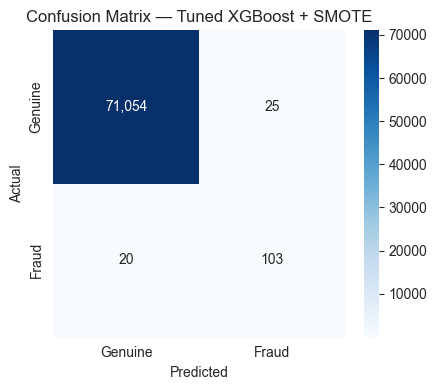

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     71079
       Fraud       0.80      0.84      0.82       123

    accuracy                           1.00     71202
   macro avg       0.90      0.92      0.91     71202
weighted avg       1.00      1.00      1.00     71202



In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Tuned XGBoost + SMOTE')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fraud']))

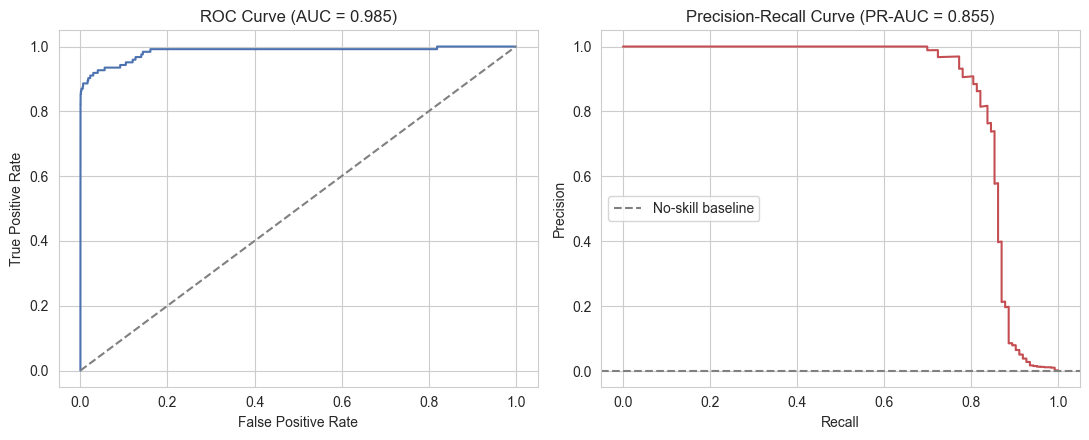

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, color='#4C72B0')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})')

axes[1].plot(rec, prec, color='#C44E52')
axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label='No-skill baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (PR-AUC = {average_precision_score(y_test, y_proba):.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

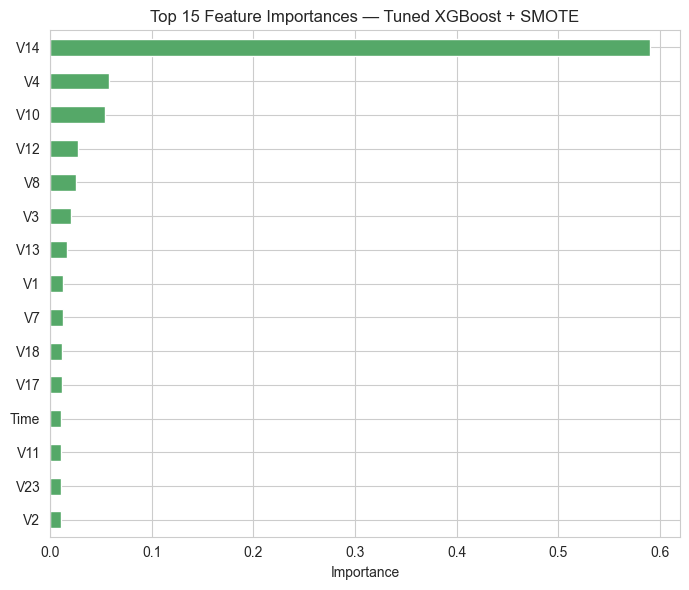

In [23]:
importances = pd.Series(best_model.named_steps['clf'].feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 15 Feature Importances — Tuned XGBoost + SMOTE')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Threshold Tuning

`predict()` uses a 0.5 cutoff by default. For fraud detection, the
business cost of a **false negative** (missed fraud) is usually much
higher than a **false positive** (a flagged genuine transaction), so
the cutoff is worth tuning explicitly rather than accepting 0.5.

Default threshold: 0.50  -> F1 = 0.8207
F1-optimal threshold: 0.9911 -> F1 = 0.8597, Precision = 0.9694, Recall = 0.7724


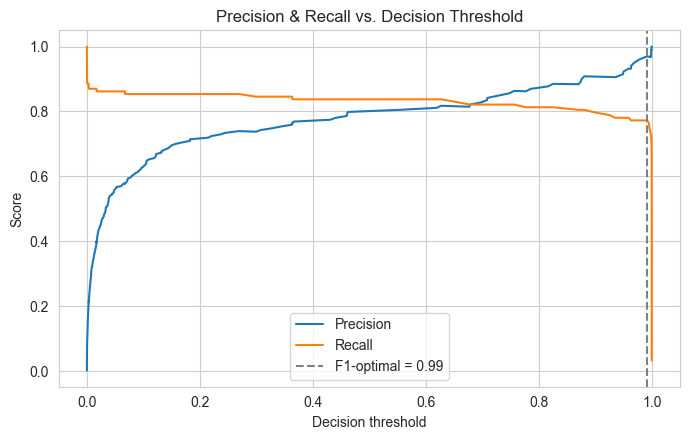


Confusion matrix at the F1-optimal threshold:
[[71076     3]
 [   28    95]]
--- Tuned XGBoost + SMOTE @ threshold=0.99 ---
Accuracy : 0.9996
Precision: 0.9694   Recall: 0.7724   F1: 0.8597
ROC-AUC  : 0.9845   PR-AUC: 0.8549
[[71076     3]
 [   28    95]]


{'model': 'Tuned XGBoost + SMOTE @ threshold=0.99',
 'accuracy': 0.9995646189713772,
 'precision': 0.9693877551020408,
 'recall': 0.7723577235772358,
 'f1': 0.8597285067873304,
 'roc_auc': 0.9845076765037688,
 'pr_auc': 0.8549105052549067}

In [24]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0,
)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Default threshold: 0.50  -> F1 = {f1_score(y_test, y_proba >= 0.5):.4f}')
print(f'F1-optimal threshold: {best_threshold:.4f} -> F1 = {f1_scores[best_idx]:.4f}, '
      f'Precision = {precisions[best_idx]:.4f}, Recall = {recalls[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.axvline(best_threshold, linestyle='--', color='grey', label=f'F1-optimal = {best_threshold:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs. Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

y_pred_tuned = (y_proba >= best_threshold).astype(int)
print('\nConfusion matrix at the F1-optimal threshold:')
print(confusion_matrix(y_test, y_pred_tuned))
evaluate_model(f'Tuned XGBoost + SMOTE @ threshold={best_threshold:.2f}', y_test, y_pred_tuned, y_proba)

## 10. Conclusion & Key Takeaways

- **Accuracy is misleading on imbalanced data.** The untouched baseline
  looked "accurate" while missing most actual fraud cases — this is
  why fraud detection is evaluated on **recall, precision, F1, ROC-AUC
  and especially PR-AUC**, not accuracy.
- **Resampling helps Logistic Regression a lot.** Class weighting,
  undersampling, and SMOTE all substantially improved recall over the
  untouched baseline, at some cost to precision — a textbook
  precision/recall trade-off.
- **Tree ensembles were tested with two imbalance strategies.**
  Decision Tree, Random Forest and XGBoost were each trained with
  native handling (`class_weight` / `scale_pos_weight`) and with SMOTE.
  Compare the paired rows in the results table (e.g. *Random Forest
  (class_weight=balanced)* vs. *Random Forest + SMOTE*) on PR-AUC and
  recall to see which works better on your data.
- **Cross-validated hyperparameter tuning** (StratifiedKFold +
  RandomizedSearchCV scored on `average_precision`) tunes XGBoost with
  SMOTE inside an `imblearn` Pipeline, so oversampling happens only on
  each fold's training portion and CV scores are not inflated by leakage.
- **Threshold tuning is a free lever.** Moving off the default 0.5
  cutoff to the F1-optimal threshold (or a business-cost-optimal one)
  changes the precision/recall balance without retraining anything.

### Possible extensions
- Unsupervised **anomaly detection** (Isolation Forest, One-Class SVM,
  or an autoencoder reconstruction-error model) for a fraud pipeline
  that doesn't rely on labeled fraud examples at all.
- **Cost-sensitive learning**: replace the F1-optimal threshold with
  one that minimizes an actual ₹/$ cost matrix (cost of a missed fraud
  vs. cost of a false alarm).
- **SHAP values** on the tuned XGBoost model for per-transaction
  explainability, which real fraud systems need for compliance.